In [1]:
from graph_tool.all import *
import numpy as np

# Susceptible: 0
# Infectado: 1
# Debilitado: 2
# Recuperado: 3

In [2]:
def swir(n, z, rho0, kappa, mu, eta):
    pER = z/n
    ss = 1 - mu - kappa
    ww = 1 - eta
    
    # inicialización del grafo erdos renyi
    g = random_graph(n, lambda: np.random.poisson((n-1) * pER), directed=False, model="erdos")

    # declarar una propiedad llamada "estado" que va a guardar el estado de cada nodo
    estado = g.new_vertex_property("short")

    # Asignar a todos los nodos el estado susceptible
    estado.get_array()[:] = 0

    # Generar rho0*n índices aleatorios
    infected_index = np.random.choice(np.arange(0, n), size=int(n*rho0), replace=False)

    # Actualizar el estado de rho0*n nodos al estado infectado
    estado.get_array()[infected_index] = 1

    # Iterador que contiene los nodos infectados
    I = [g.vertex(i) for i in infected_index]
    
    def reaction(vertex):
        """
        Función que realiza un paso de tiempo para un nodo infectado:
        vertex es un nodo en estado infectado.
        """
        # actualiza el estado del nodo actual infectado a recuperado
        estado[vertex] = 3
        # obtiene los vecinos del nodo infectado
        vecinos = vertex.out_neighbors()
        # lista de índices de vecinos susceptibles
        S = np.array([g.vertex_index[v] for v in vecinos if estado[v]==0]).astype(int)
        #obtiene los vecinos del nodo infectado, de nuevo.
        vecinos = vertex.out_neighbors()
        # lista de índices de vecinos debilitados
        W = np.array([g.vertex_index[v] for v in vecinos if estado[v]==2]).astype(int)
        # calcula nuevos estados de los vecinos susceptibles
        new_states = np.random.choice([0, 1, 2], size=S.size, p=[ss, kappa, mu])
        # actualiza estados de vecinos susceptibles
        estado.get_array()[S] = new_states
        # inicia lista de nuevos nodos infectados con los susceptibles que se infectaron
        new_infected = [g.vertex(i) for i in S[new_states==1]]
        # calcula nuevos estados de los vecinos debilitados
        new_states = np.random.choice([2, 1], size=W.size, p=[ww, eta])
        # actualiza estados de vecinos debilitados
        estado.get_array()[W] = new_states
        # actualiza lista de nuevos nodos infectados con los debilitados que se infectaron
        new_infected += [g.vertex(i) for i in W[new_states==1]]
        # devuelve los vecinos que se infectaron
        return new_infected
    while I:
        # inicia una lista que guarda los nodos que serán infectados en el paso de tiempo n
        new_infected_n = []
        # itera sobre los nodos infectados
        for i in I:
            # hace que el nodo infectado reaccione con sus vecinos
            ni = reaction(i)
            # agrega los vecinos infectados a la lista de los nuevos infectados
            new_infected_n.append(ni)
        # actualiza la lista de los nuevos infectados para el paso de tiempo n+1
        I = [s for sublist in new_infected_n for s in sublist]
        np.random.shuffle(I)
    return estado.get_array()

In [3]:
from pathos.multiprocessing import ProcessingPool as Pool
import tqdm
import pickle

In [ ]:
N = 10000
def worker_function(num_ensamble, N):
    kappa_range = (np.linspace(-1, 1, 20))**3
    max_new = 0.115+0.003
    min_new = 0.115-0.003
    kappa_range = (kappa_range-kappa_range.min()) * (max_new - min_new) / 2 + min_new
    results = []
    for kappa in kappa_range:
        results.append(swir(N, 8, 2e-3, kappa, kappa, 0.5))
    with open('./results/{0}_{1}.p'.format(num_ensamble, N), "wb") as f:
        pickle.dump(results, f)

ensambles = 100
with Pool(4) as pool:
    results = list(tqdm.tqdm(pool.imap(worker_function, range(ensambles), (N for n in range(ensambles))),
                                       total=ensambles))

 80%|████████  | 80/100 [03:06<00:44,  2.21s/it]

In [5]:
ms = []
for r in results:
    m = np.count_nonzero(r == 3)/N
    ms.append(m)

In [6]:
import matplotlib.pyplot as plt

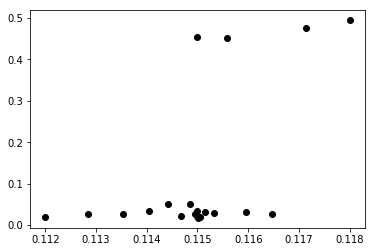

In [7]:
plt.plot(kappa_range, ms, 'ko')

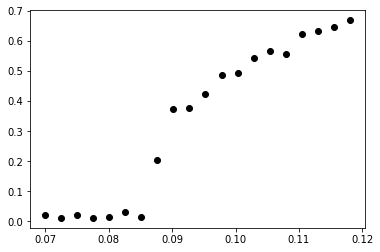

In [10]:
plt.plot(kappa_range, ms, 'ko')

In [32]:
from time import time

Ns = [int(n) for n in np.geomspace(100, 100000, 7)]
times = []
for n in Ns:
    t0 = time()
    est = swir(n, 8, 0.1, 0.2, 0.1, 0.1)
    t = time()-t0
    print(t)
    times.append(t)

0.020766258239746094
0.07914113998413086
0.26991915702819824
0.8224437236785889
2.5991108417510986
8.290196895599365
26.28043270111084


In [34]:
z = np.polyfit(np.log(Ns), np.log(times), 1)
p = np.poly1d(z)
print(np.exp(p(np.log(40e6)))/60/24)

8.762609772619713
